# 05 - So sanh Face Detection Models (SCRFD vs YOLOv8-Face vs MTCNN)

**Muc tieu:** notebook nay bo sung cho quyet dinh kien truc da chot o `ai/README.md`
("da bo RetinaFace, dung insightface/SCRFD cho ca detect+embedding") bang so lieu dinh
luong thuc te - so sanh SCRFD voi 2 kien truc face detector khac de chung minh lua chon
hien tai la hop ly, khong phai chi vi "chay duoc tren Python 3.13".

**3 model duoc so sanh (3 nhom kien truc khac nhau):**

| Model | Kien truc | Vai tro trong so sanh |
|---|---|---|
| **SCRFD** (qua `insightface`, buffalo_l) | Anchor-free, single-stage, ONNX Runtime | Model **dang dung that** trong `backend/` |
| **YOLOv8-face** | YOLO backbone (anchor-free), fine-tune rieng cho mat | Cung ho YOLO nhu person detector (`yolov8n.pt`) dang dung, nhung chuyen biet cho mat |
| **MTCNN** | Cascade CNN 3 tang (P-Net/R-Net/O-Net), kien truc co dien hon | Baseline "kinh dien" de thay ro cai gia phai tra khi dung kien truc cu hon |

**Bo du lieu danh gia:** WIDER FACE validation split, tai da co san trong
`ai/dataset/benchmarks/wider face/` (dung lai cau truc doc annotation tu Notebook 04,
Cell 8-10) - KHONG tai lai, KHONG doi cau truc thu muc.

**Phan cung:** may chay co GPU RTX 5070 (12GB VRAM, kien truc Blackwell) - notebook nay
uu tien chay ca 3 model tren GPU (CUDA) de so sanh **ca do chinh xac LAN toc do** cong
bang tren cung 1 phan cung, thay vi chi so sanh accuracy don thuan.

**Cac phan doc lap co the chay rieng:**
- Phan A - Cai dat + tai 3 model
- Phan B - Danh gia tren WIDER FACE (Precision/Recall/F1 @ IoU>=0.5, recall theo kich thuoc mat)
- Phan C - Do toc do (FPS) tren GPU
- Phan D - So sanh truc quan tren vai anh mau
- Phan E - Tong ket + bang so lieu cho bao cao

## Phan A - Cai dat thu vien va tai 3 model

`insightface` + `onnxruntime-gpu` va `ultralytics` (YOLOv8) da co tu Notebook 01/02.
Moi trong notebook nay: `facenet-pytorch` (MTCNN) va ban YOLOv8-face rieng (khong phai
`yolov8n.pt` phat hien NGUOI dang dung trong `backend/`, day la ban fine-tune cho MAT).

**Luu y ve `onnxruntime` GPU:** insightface dung ONNX Runtime, can ban `onnxruntime-gpu`
(khong phai `onnxruntime` CPU-only) de chay tren RTX 5070 qua CUDA Execution Provider.
Neu may da cai `onnxruntime` (CPU) tu Notebook 01, can go ra truoc roi cai lai ban GPU -
2 package nay xung dot nhau (cung import ten `onnxruntime`).

**CANH BAO QUAN TRONG ve `facenet-pytorch` (ban 2.6.0, phat hanh 2024, khong con duoc
cap nhat):** package nay khai bao cung (pin) `torch>=2.2.0,<2.3.0`, `torchvision>=0.17.0,
<0.18.0`, `numpy<2.0.0`, `Pillow<10.3.0` trong metadata. RTX 5070 (kien truc Blackwell,
sm_120) can `torch>=2.7.0` (build cu128 tro len) moi co CUDA kernel ho tro - neu
`pip install facenet-pytorch` binh thuong, pip se co HA CAP torch xuong `<2.3.0` de thoa
rang buoc, lam MAT CUDA support tren GPU nay (MTCNN se roi ve CPU hoac loi thang).

**Cach xu ly trong notebook nay:** cai `facenet-pytorch` voi co `--no-deps` (bo qua
rang buoc dependency khai bao) de giu nguyen ban torch/torchvision/numpy dang dung cho
RTX 5070, roi tu cai bu 2 dependency KHONG lien quan torch (`requests`, `tqdm`) rieng.
Da kiem tra: ma nguon `facenet_pytorch` (MTCNN, InceptionResnetV1) chi dung cac API
`torch.nn` pho thong (Conv2d, BatchNorm, v.v.), KHONG co doan nao kiem tra
`torch.__version__` cung luc chay - nen rui ro tuong thich API la THAP, nhung khong
phai KHONG CO, vi day la cach lam trai voi rang buoc nha phat trien da khai bao. Neu
sau nay MTCNN bao loi la lien quan phien ban torch, day la nghi pham dau tien can kiem tra.

In [1]:
# ===== CELL A1: Go ban onnxruntime CPU (neu co) & cai ban GPU =====
# Neu may chua tung cai onnxruntime CPU, dong pip uninstall se chi bao "not installed", khong sao.
!pip uninstall onnxruntime -y -q
!pip install -q onnxruntime-gpu

# facenet-pytorch (2.6.0) pin torch<2.3.0 trong metadata - RTX 5070 can torch>=2.7.0.
# Cai --no-deps de KHONG bi pip ha cap torch dang dung, roi tu cai bu 2 dependency
# khong lien quan torch (requests, tqdm) rieng - xem canh bao chi tiet o markdown tren.
!pip install -q --no-deps facenet-pytorch
!pip install -q requests tqdm

print("Da cai: onnxruntime-gpu (cho insightface/SCRFD), facenet-pytorch --no-deps (cho MTCNN)")
print("ultralytics (YOLOv8) va insightface da co tu Notebook 01/02, khong can cai lai")


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Da cai: onnxruntime-gpu (cho insightface/SCRFD), facenet-pytorch --no-deps (cho MTCNN)
ultralytics (YOLOv8) va insightface da co tu Notebook 01/02, khong can cai lai



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ===== CELL A1b: Xac nhan torch KHONG bi ha cap sau khi cai facenet-pytorch =====
import torch
print(f"Torch version sau khi cai facenet-pytorch: {torch.__version__}")
if torch.__version__.startswith(("2.0.", "2.1.", "2.2.")):
    print("CANH BAO: torch da bi ha cap xuong ban cu (< 2.3) - facenet-pytorch co the da "
          "duoc cai KHONG dung --no-deps, hoac 1 package khac keo torch xuong. RTX 5070 "
          "se KHONG chay duoc CUDA voi ban torch nay - can go va cai lai torch>=2.7 (cu128).")
else:
    print("Torch van dang o ban moi, chua bi facenet-pytorch keo xuong. On.")

Torch version sau khi cai facenet-pytorch: 2.11.0+cu128
Torch van dang o ban moi, chua bi facenet-pytorch keo xuong. On.


In [3]:
# ===== CELL A2: Kiem tra GPU co duoc nhan dien khong (PyTorch + ONNX Runtime) =====
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("KHONG thay GPU - kiem tra lai driver/CUDA toolkit truoc khi chay tiep, "
          "cac phep do FPS o Phan C se khong con y nghia so sanh voi GPU neu roi ve CPU.")

import onnxruntime as ort
print(f"\nONNX Runtime providers co san: {ort.get_available_providers()}")
if "CUDAExecutionProvider" not in ort.get_available_providers():
    print("CANH BAO: khong thay CUDAExecutionProvider - SCRFD se chay CPU (cham hon nhieu, "
          "so sanh FPS o Phan C se khong con cong bang giua 3 model).")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5070
VRAM: 12.8 GB

ONNX Runtime providers co san: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [4]:
# ===== CELL A3: Duong dan project (giong quy uoc cac notebook truoc) =====
import os

BASE_DIR = r'D:\face-security-system'
AI_DIR = os.path.join(BASE_DIR, 'ai')

BENCHMARK_DIR = os.path.join(AI_DIR, 'dataset', 'benchmarks')
WIDER_FACE_DIR = os.path.join(BENCHMARK_DIR, 'wider face')
WIDER_VAL_IMAGES_DIR = os.path.join(WIDER_FACE_DIR, 'WIDER_val', 'images')
WIDER_VAL_ANNOTATION_PATH = os.path.join(
    WIDER_FACE_DIR, 'wider_face_annotations', 'wider_face_split', 'wider_face_val_bbx_gt.txt'
)

MODELS_DIR = os.path.join(AI_DIR, 'models')
RESULTS_DIR = os.path.join(AI_DIR, 'dataset', 'evaluation_results')
os.makedirs(RESULTS_DIR, exist_ok=True)

WIDER_FACE_AVAILABLE = os.path.exists(WIDER_VAL_IMAGES_DIR) and os.path.exists(WIDER_VAL_ANNOTATION_PATH)
if not WIDER_FACE_AVAILABLE:
    print("KHONG tim thay du lieu WIDER FACE tai:")
    print(f"  Anh:        {WIDER_VAL_IMAGES_DIR}")
    print(f"  Annotation: {WIDER_VAL_ANNOTATION_PATH}")
    print("Day la du lieu da tai o Notebook 04 - kiem tra lai duong dan BASE_DIR o tren "
          "neu chay tren may khac may da tai du lieu.")
else:
    print("Da tim thay du lieu WIDER FACE, san sang cho Phan B.")

Da tim thay du lieu WIDER FACE, san sang cho Phan B.


In [5]:
# ===== CELL A4: Tai model 1 - SCRFD (qua insightface, buffalo_l) =====
# Day chinh la model dang dung THAT trong backend/app/services/face_recognition_service.py
from insightface.app import FaceAnalysis

providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
scrfd_app = FaceAnalysis(name="buffalo_l", providers=providers)
# ctx_id=0 -> GPU dau tien neu CUDAExecutionProvider co san, insightface tu rot ve CPU neu khong
scrfd_app.prepare(ctx_id=0, det_size=(640, 640), det_thresh=0.3)  # det_thresh giong het config.py

print("Da tai SCRFD (buffalo_l)")
print(f"Providers dang dung: {scrfd_app.det_model.session.get_providers()}")

d:\face-security-system\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
find model: C:\Users\Admin/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'

In [6]:
# ===== CELL A5: Tai model 2 - YOLOv8-face =====
YOLOV8_FACE_PATH = os.path.join(MODELS_DIR, "yolov8n-face.pt")

if not os.path.exists(YOLOV8_FACE_PATH):
    import urllib.request
    os.makedirs(MODELS_DIR, exist_ok=True)

    # Danh sach URL thu lan luot (fallback)
    urls = [
        # Thu 1: repo akanametov, tag v1.0.0 (tag cu v0.0.0 da bi xoa model)
        "https://github.com/akanametov/yolo-face/releases/download/v1.0.0/yolov8n-face.pt",
        # Thu 2: HuggingFace mirror
        "https://huggingface.co/deepghs/yolo-face/resolve/main/yolov8n-face/model.pt",
        # Thu 3: repo lindevs (ten file hoi khac)
        "https://github.com/lindevs/yolov8-face/releases/download/1.0.1/yolov8n-face-lindevs.pt",
    ]

    downloaded = False
    for url in urls:
        try:
            print(f"Dang tai YOLOv8n-face tu {url} ...")
            urllib.request.urlretrieve(url, YOLOV8_FACE_PATH)
            print("Da tai xong.")
            downloaded = True
            break
        except Exception as e:
            print(f"  -> Loi: {e}")
            # Xoa file tam neu tai that bai giua chung
            if os.path.exists(YOLOV8_FACE_PATH):
                os.remove(YOLOV8_FACE_PATH)

    if not downloaded:
        raise RuntimeError(
            "Khong the tai yolov8n-face.pt tu bat ky nguon nao. "
            "Vui long tai thu cong va dat vao: " + YOLOV8_FACE_PATH
        )
else:
    print("Da co san checkpoint, khong tai lai.")

from ultralytics import YOLO
yolo_face_model = YOLO(YOLOV8_FACE_PATH)
print(f"Da tai YOLOv8-face, se chay tren: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Da co san checkpoint, khong tai lai.
Da tai YOLOv8-face, se chay tren: cuda


In [7]:
# ===== CELL A6: Tai model 3 - MTCNN (cascade CNN co dien, qua facenet-pytorch) =====
from facenet_pytorch import MTCNN

device = "cuda" if torch.cuda.is_available() else "cpu"
mtcnn_model = MTCNN(
    keep_all=True,       # tra ve TAT CA mat tim duoc trong anh, khong chi 1 mat dep nhat
    device=device,
    min_face_size=20,     # gan giong nguong mac dinh cua SCRFD/YOLOv8-face de so sanh cong bang
    thresholds=[0.6, 0.7, 0.7],  # nguong 3 tang P-Net/R-Net/O-Net mac dinh cua MTCNN goc
)
print(f"Da tai MTCNN, dang chay tren: {device}")

Da tai MTCNN, dang chay tren: cuda


## Phan B - Danh gia tren WIDER FACE

Truoc khi do, can 1 ham **wrapper thong nhat** cho ca 3 model - vi moi thu vien tra ve
bounding box theo dinh dang khac nhau (insightface: `(x1,y1,x2,y2)` tuyet doi; YOLOv8:
tuong tu nhung qua object `.boxes`; MTCNN: `(x1,y1,x2,y2)` hoac `None` neu khong thay mat).
Chuan hoa het ve 1 dinh dang chung `[x1, y1, x2, y2]` (pixel, goc tren-trai) truoc khi tinh IoU.

Ham `iou_xywh` va cach doc annotation WIDER FACE **dung lai y het Notebook 04** (Cell 8-9)
de ket qua so sanh duoc voi threshold/logic da dung khi danh gia SCRFD rieng le truoc do.

In [8]:
# ===== CELL B1: Doc annotation WIDER FACE (giong het Notebook 04, Cell 8) =====
def parse_wider_face_annotations(annotation_path):
    # Tra ve dict {duong_dan_anh_tuong_doi: [[x,y,w,h], ...]} tu file .txt goc WIDER FACE.
    annotations = {}
    with open(annotation_path, "r") as f:
        lines = [l.strip() for l in f.readlines()]

    i = 0
    while i < len(lines):
        img_path = lines[i]
        i += 1
        n_faces = int(lines[i])
        i += 1
        boxes = []
        # WIDER FACE ghi n_faces=0 nhung VAN co 1 dong "0 0 0 0 0 0 0 0 0 0" phia sau
        n_read = max(n_faces, 1)
        for _ in range(n_read):
            parts = lines[i].split()
            x, y, w, h = map(int, parts[:4])
            if w > 0 and h > 0:
                boxes.append([x, y, w, h])
            i += 1
        annotations[img_path] = boxes

    return annotations


if WIDER_FACE_AVAILABLE:
    wider_annotations = parse_wider_face_annotations(WIDER_VAL_ANNOTATION_PATH)
    print(f"Da doc {len(wider_annotations)} anh tu annotation WIDER FACE")
else:
    wider_annotations = {}
    print("Bo qua - WIDER FACE chua san sang (xem Cell A3)")

Da doc 3226 anh tu annotation WIDER FACE


In [9]:
# ===== CELL B2: Ham tinh IoU (dinh dang xywh - giong het Notebook 04, Cell 9) =====
import cv2
import numpy as np


def iou_xywh(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    xa1, ya1, xa2, ya2 = x1, y1, x1 + w1, y1 + h1
    xb1, yb1, xb2, yb2 = x2, y2, x2 + w2, y2 + h2

    inter_x1, inter_y1 = max(xa1, xb1), max(ya1, yb1)
    inter_x2, inter_y2 = min(xa2, xb2), min(ya2, yb2)
    inter_w, inter_h = max(0, inter_x2 - inter_x1), max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    union_area = w1 * h1 + w2 * h2 - inter_area
    return inter_area / union_area if union_area > 0 else 0.0


print("Da dinh nghia iou_xywh()")

Da dinh nghia iou_xywh()


In [10]:
# ===== CELL B3: Wrapper thong nhat - moi model tra ve list [x1, y1, x2, y2] pixel tuyet doi =====

def detect_scrfd(img_bgr):
    faces = scrfd_app.get(img_bgr)
    return [f.bbox.astype(int).tolist() for f in faces]


def detect_yolov8_face(img_bgr, conf=0.3):
    results = yolo_face_model.predict(img_bgr, conf=conf, verbose=False, device=device)
    boxes = []
    for r in results:
        if r.boxes is not None:
            for b in r.boxes.xyxy.cpu().numpy():
                boxes.append(b.astype(int).tolist())
    return boxes


def detect_mtcnn(img_bgr):
    # MTCNN (facenet-pytorch) mong doi anh RGB dang PIL/numpy, khong phai BGR nhu OpenCV
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    boxes, _ = mtcnn_model.detect(img_rgb)
    if boxes is None:
        return []
    return [[int(x1), int(y1), int(x2), int(y2)] for x1, y1, x2, y2 in boxes]


DETECTORS = {
    "SCRFD (insightface)": detect_scrfd,
    "YOLOv8-face": detect_yolov8_face,
    "MTCNN": detect_mtcnn,
}

print(f"Da dinh nghia {len(DETECTORS)} ham detect thong nhat: {list(DETECTORS.keys())}")

Da dinh nghia 3 ham detect thong nhat: ['SCRFD (insightface)', 'YOLOv8-face', 'MTCNN']


In [11]:
# ===== CELL B4: Chay danh gia Precision/Recall/F1 @ IoU>=0.5 cho CA 3 MODEL =====
# Dung chung N_EVAL_IMAGES voi Notebook 04 de so sanh duoc truc tiep - tang len neu
# muon danh gia ky hon cho bao cao (toan bo WIDER FACE val la ~3200 anh).
N_EVAL_IMAGES = 200
IOU_THRESHOLD = 0.5

image_level_results = []   # 1 dong / anh / model
box_level_results = []     # 1 dong / GT box / model (de tinh recall theo kich thuoc mat)

if not WIDER_FACE_AVAILABLE:
    print("Bo qua Cell nay - WIDER FACE chua san sang (xem Cell A3)")
else:
    image_keys = list(wider_annotations.keys())[:N_EVAL_IMAGES]
    n_images = len(image_keys)

    for model_name, detect_fn in DETECTORS.items():
        print(f"\n--- Dang chay {model_name} tren {n_images} anh ---")

        for idx, img_rel_path in enumerate(image_keys):
            img_full_path = os.path.join(WIDER_VAL_IMAGES_DIR, img_rel_path)
            img_bgr = cv2.imread(img_full_path)
            if img_bgr is None:
                continue

            gt_boxes = wider_annotations[img_rel_path]  # [[x,y,w,h], ...]
            pred_boxes_xyxy = detect_fn(img_bgr)
            # doi predicted box ve xywh de dung chung 1 ham iou_xywh voi GT
            pred_boxes = [[x1, y1, x2 - x1, y2 - y1] for x1, y1, x2, y2 in pred_boxes_xyxy]

            matched_gt = set()
            tp = 0
            for pb in pred_boxes:
                best_iou, best_gt_idx = 0.0, -1
                for gi, gb in enumerate(gt_boxes):
                    if gi in matched_gt:
                        continue
                    iou = iou_xywh(pb, gb)
                    if iou > best_iou:
                        best_iou, best_gt_idx = iou, gi
                if best_iou >= IOU_THRESHOLD:
                    tp += 1
                    matched_gt.add(best_gt_idx)

            fp = len(pred_boxes) - tp
            fn = len(gt_boxes) - len(matched_gt)

            image_level_results.append({
                "model": model_name, "image": img_rel_path,
                "n_gt": len(gt_boxes), "n_pred": len(pred_boxes),
                "tp": tp, "fp": fp, "fn": fn,
            })

            for gi, gb in enumerate(gt_boxes):
                _, _, w, h = gb
                face_size = min(w, h)
                size_bucket = "small" if face_size < 32 else ("medium" if face_size < 96 else "large")
                box_level_results.append({
                    "model": model_name, "image": img_rel_path,
                    "size_bucket": size_bucket, "detected": gi in matched_gt,
                })

            if (idx + 1) % 50 == 0:
                print(f"  {idx + 1}/{n_images} anh...")

    print("\nDa chay xong danh gia cho ca 3 model.")


--- Dang chay SCRFD (insightface) tren 200 anh ---


d:\face-security-system\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


  50/200 anh...
  100/200 anh...
  150/200 anh...
  200/200 anh...

--- Dang chay YOLOv8-face tren 200 anh ---
  50/200 anh...
  100/200 anh...
  150/200 anh...
  200/200 anh...

--- Dang chay MTCNN tren 200 anh ---
  50/200 anh...
  100/200 anh...
  150/200 anh...
  200/200 anh...

Da chay xong danh gia cho ca 3 model.


In [12]:
# ===== CELL B5: Tong hop Precision/Recall/F1 tung model =====
import pandas as pd

if not WIDER_FACE_AVAILABLE:
    print("Bo qua Cell nay - WIDER FACE chua san sang")
else:
    image_df = pd.DataFrame(image_level_results)
    box_df = pd.DataFrame(box_level_results)

    summary_rows = []
    for model_name in DETECTORS.keys():
        sub = image_df[image_df["model"] == model_name]
        total_tp, total_fp, total_fn = sub["tp"].sum(), sub["fp"].sum(), sub["fn"].sum()

        precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
        recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        summary_rows.append({
            "model": model_name, "precision": round(precision, 4),
            "recall": round(recall, 4), "f1": round(f1, 4),
            "total_gt_faces": int(sub["n_gt"].sum()),
            "total_predictions": int(sub["n_pred"].sum()),
        })

    summary_df = pd.DataFrame(summary_rows)
    print(f"Precision/Recall/F1 @ IoU>={IOU_THRESHOLD} tren {n_images} anh WIDER FACE val:\n")
    print(summary_df.to_string(index=False))

    summary_df.to_csv(os.path.join(RESULTS_DIR, "face_detector_comparison_summary.csv"), index=False)
    image_df.to_csv(os.path.join(RESULTS_DIR, "face_detector_comparison_image_level.csv"), index=False)

Precision/Recall/F1 @ IoU>=0.5 tren 200 anh WIDER FACE val:

              model  precision  recall     f1  total_gt_faces  total_predictions
SCRFD (insightface)     0.8165  0.6001 0.6918            6317               4643
        YOLOv8-face     0.8803  0.5170 0.6514            6317               3710
              MTCNN     0.9187  0.3345 0.4904            6317               2300


In [13]:
# ===== CELL B6: Recall theo kich thuoc mat (small/medium/large) - ban chat cua so sanh nay =====
# Day la con so QUAN TRONG NHAT cho bao cao: WIDER FACE co rat nhieu mat NHO (dam dong,
# camera an ninh o xa) - model nao giu duoc recall cao o nhom "small" moi thuc su phu
# hop cho bai toan giam sat an ninh, khong chi accuracy tong the tren anh de (mat lon, gan).

if not WIDER_FACE_AVAILABLE:
    print("Bo qua Cell nay - WIDER FACE chua san sang")
else:
    recall_by_size = (
        box_df.groupby(["model", "size_bucket"])["detected"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "recall", "count": "n_faces"})
        .reset_index()
    )
    size_order = pd.Categorical(recall_by_size["size_bucket"], categories=["small", "medium", "large"], ordered=True)
    recall_by_size = recall_by_size.assign(size_bucket=size_order).sort_values(["model", "size_bucket"])

    print("Recall theo kich thuoc mat (small: <32px, medium: 32-96px, large: >=96px canh ngan nhat):\n")
    print(recall_by_size.to_string(index=False))

    recall_by_size.to_csv(os.path.join(RESULTS_DIR, "face_detector_comparison_recall_by_size.csv"), index=False)

Recall theo kich thuoc mat (small: <32px, medium: 32-96px, large: >=96px canh ngan nhat):

              model size_bucket   recall  n_faces
              MTCNN       small 0.271214     5586
              MTCNN      medium 0.812596      651
              MTCNN       large 0.862500       80
SCRFD (insightface)       small 0.554064     5586
SCRFD (insightface)      medium 0.946237      651
SCRFD (insightface)       large 1.000000       80
        YOLOv8-face       small 0.470999     5586
        YOLOv8-face      medium 0.855607      651
        YOLOv8-face       large 0.975000       80


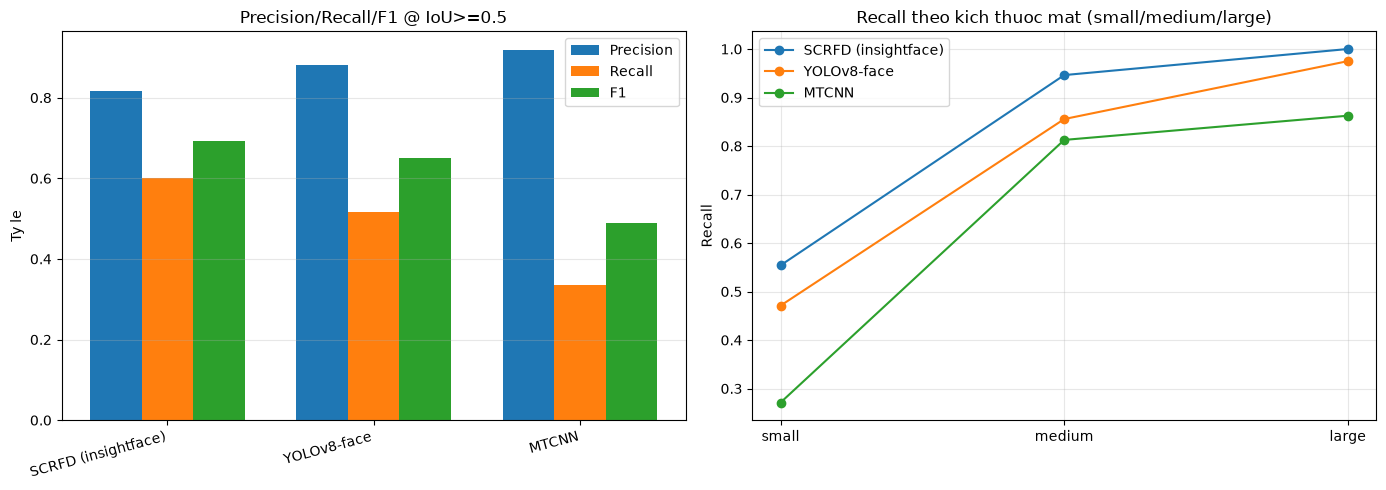

Da luu bieu do: D:\face-security-system\ai\dataset\evaluation_results\face_detector_comparison.png


In [14]:
# ===== CELL B7: Bieu do so sanh Precision/Recall/F1 + Recall theo kich thuoc mat =====
import matplotlib.pyplot as plt

if not WIDER_FACE_AVAILABLE:
    print("Bo qua Cell nay - WIDER FACE chua san sang")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bieu do 1: Precision/Recall/F1 tong the
    x = np.arange(len(summary_df))
    width = 0.25
    axes[0].bar(x - width, summary_df["precision"], width, label="Precision")
    axes[0].bar(x, summary_df["recall"], width, label="Recall")
    axes[0].bar(x + width, summary_df["f1"], width, label="F1")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(summary_df["model"], rotation=15, ha="right")
    axes[0].set_ylabel("Ty le")
    axes[0].set_title(f"Precision/Recall/F1 @ IoU>={IOU_THRESHOLD}")
    axes[0].legend()
    axes[0].grid(alpha=0.3, axis="y")

    # Bieu do 2: Recall theo kich thuoc mat - moi model 1 duong
    for model_name in DETECTORS.keys():
        sub = recall_by_size[recall_by_size["model"] == model_name]
        axes[1].plot(sub["size_bucket"].astype(str), sub["recall"], marker="o", label=model_name)
    axes[1].set_ylabel("Recall")
    axes[1].set_title("Recall theo kich thuoc mat (small/medium/large)")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plot_path = os.path.join(RESULTS_DIR, "face_detector_comparison.png")
    plt.savefig(plot_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Da luu bieu do: {plot_path}")

## Phan C - Do toc do (FPS) tren GPU

Accuracy khong phai tat ca - he thong nay chay **real-time tren stream camera**
(`backend/app/services/pipeline_runner.py`), nen toc do quyet dinh model co dung duoc
cho production hay khong, khong chi de trong bao cao. Do bang cach chay 100 anh lien tiep
qua tung model, tinh FPS trung binh (bo qua vai lan dau de "warm-up" GPU/model).

In [15]:
# ===== CELL C1: Do FPS cho ca 3 model tren cung tap anh, cung GPU =====
import time

N_WARMUP = 5
N_TIMED = 100

speed_results = []

if not WIDER_FACE_AVAILABLE:
    print("Bo qua Cell nay - can anh WIDER FACE de do FPS tren du lieu thuc te")
else:
    timing_images = []
    for img_rel_path in list(wider_annotations.keys())[:N_WARMUP + N_TIMED]:
        img = cv2.imread(os.path.join(WIDER_VAL_IMAGES_DIR, img_rel_path))
        if img is not None:
            timing_images.append(img)

    for model_name, detect_fn in DETECTORS.items():
        print(f"Dang do toc do {model_name}...")

        # Warm-up - lan chay dau tien cua GPU model thuong cham hon han do khoi tao kernel CUDA
        for img in timing_images[:N_WARMUP]:
            detect_fn(img)

        if device == "cuda" or torch.cuda.is_available():
            torch.cuda.synchronize()

        start = time.time()
        for img in timing_images[N_WARMUP:N_WARMUP + N_TIMED]:
            detect_fn(img)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        elapsed = time.time() - start

        n_processed = len(timing_images[N_WARMUP:N_WARMUP + N_TIMED])
        fps = n_processed / elapsed if elapsed > 0 else 0.0
        ms_per_image = (elapsed / n_processed) * 1000 if n_processed > 0 else 0.0

        speed_results.append({
            "model": model_name, "fps": round(fps, 2),
            "ms_per_image": round(ms_per_image, 2), "n_images_timed": n_processed,
        })

    speed_df = pd.DataFrame(speed_results)
    print(f"\nToc do xu ly (batch size = 1, {'GPU: ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}):\n")
    print(speed_df.to_string(index=False))
    speed_df.to_csv(os.path.join(RESULTS_DIR, "face_detector_comparison_speed.csv"), index=False)

Dang do toc do SCRFD (insightface)...


d:\face-security-system\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


Dang do toc do YOLOv8-face...
Dang do toc do MTCNN...

Toc do xu ly (batch size = 1, GPU: NVIDIA GeForce RTX 5070):

              model    fps  ms_per_image  n_images_timed
SCRFD (insightface)   4.34        230.42             100
        YOLOv8-face 157.37          6.35             100
              MTCNN   9.14        109.36             100


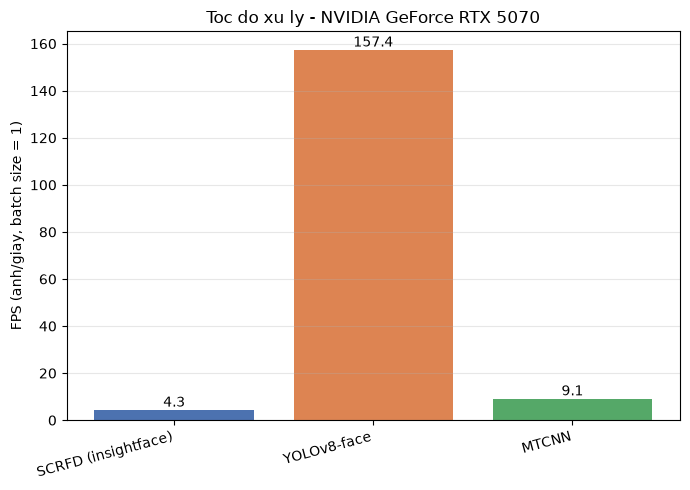

Da luu bieu do: D:\face-security-system\ai\dataset\evaluation_results\face_detector_speed_comparison.png


In [16]:
# ===== CELL C2: Bieu do FPS =====
if not WIDER_FACE_AVAILABLE:
    print("Bo qua Cell nay - chua co ket qua toc do")
else:
    plt.figure(figsize=(7, 5))
    bars = plt.bar(speed_df["model"], speed_df["fps"], color=["#4C72B0", "#DD8452", "#55A868"])
    plt.ylabel("FPS (anh/giay, batch size = 1)")
    plt.title("Toc do xu ly - " + (torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"))
    plt.xticks(rotation=15, ha="right")
    for bar, fps in zip(bars, speed_df["fps"]):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{fps:.1f}",
                  ha="center", va="bottom")
    plt.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plot_path = os.path.join(RESULTS_DIR, "face_detector_speed_comparison.png")
    plt.savefig(plot_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Da luu bieu do: {plot_path}")

## Phan D - So sanh truc quan tren vai anh mau

Ve bounding box cua ca 3 model tren cung 1 anh, canh nhau - de "nhin thay bang mat"
khac biet (vi du MTCNN co the bo sot mat nho trong dam dong ma SCRFD/YOLOv8-face bat
duoc), bo sung truc quan cho bang so lieu o Phan B.

d:\face-security-system\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


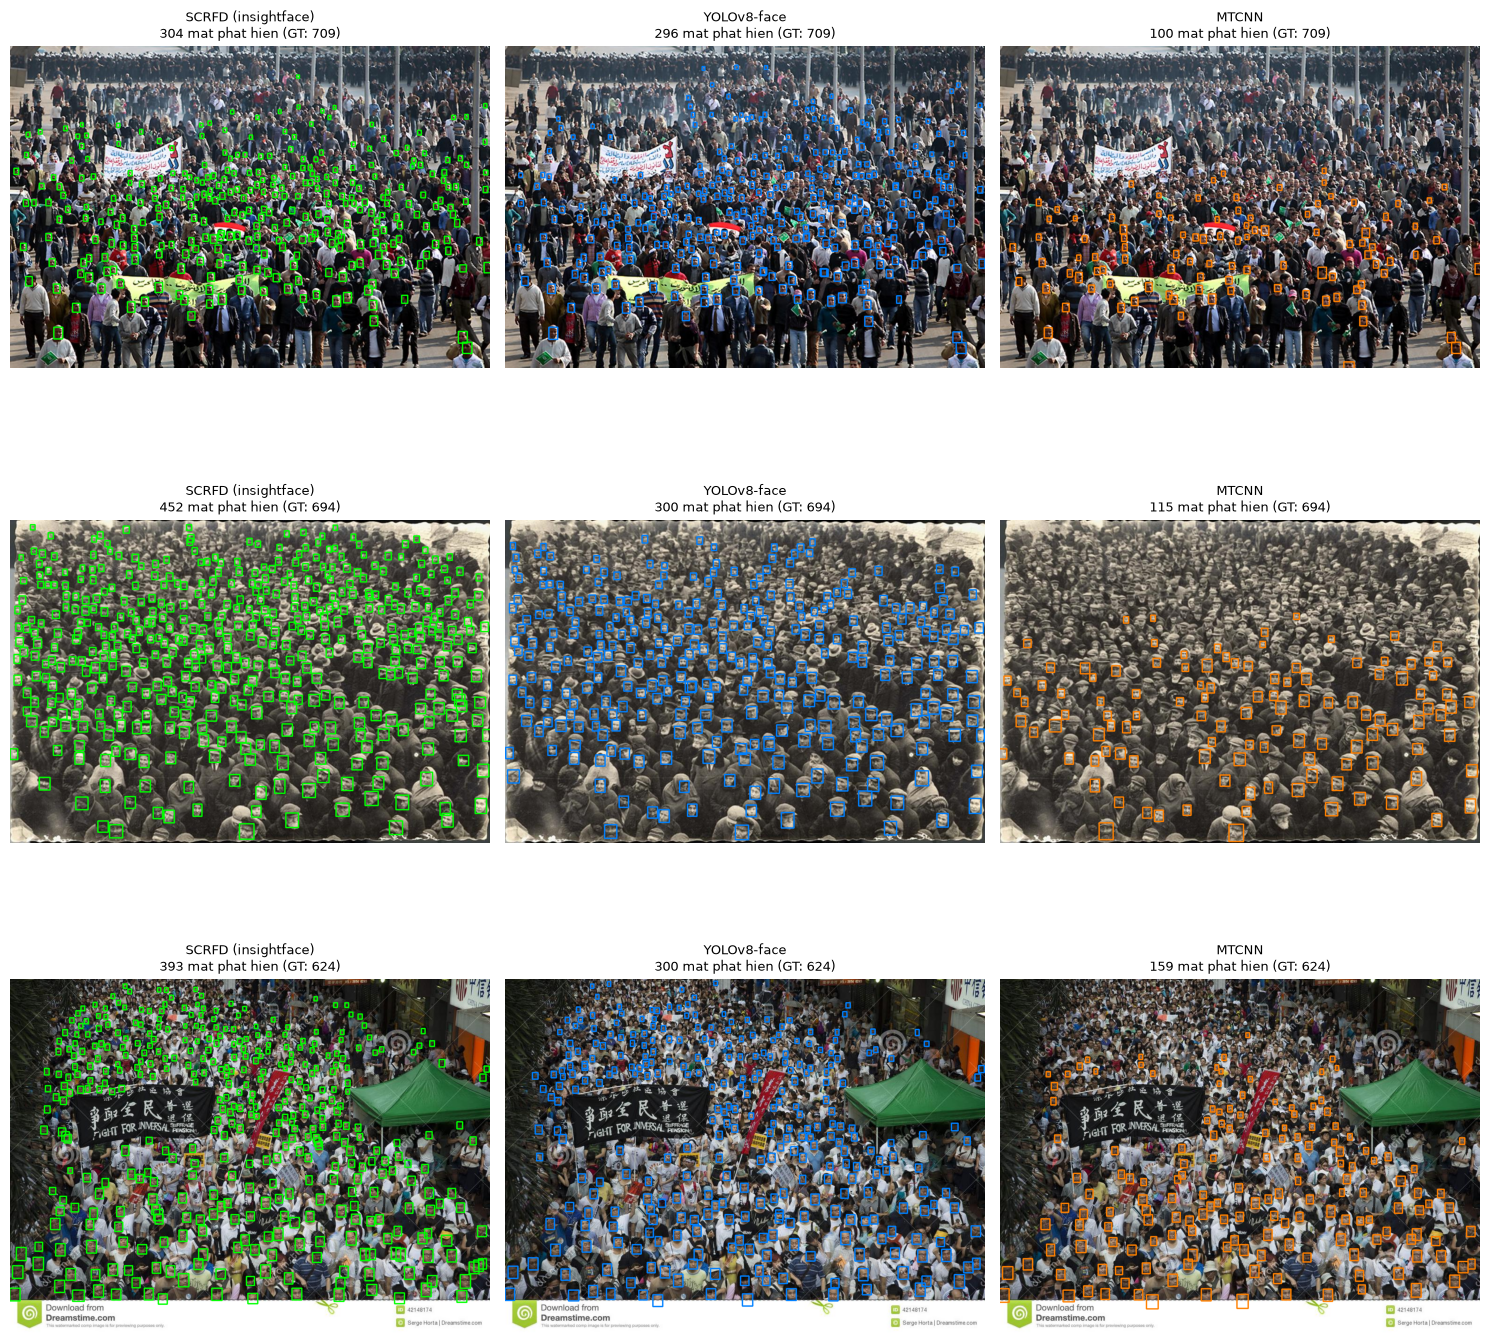

Da luu anh so sanh: D:\face-security-system\ai\dataset\evaluation_results\face_detector_visual_comparison.png


In [17]:
# ===== CELL D1: Ve bounding box cua ca 3 model tren vai anh mau tu WIDER FACE =====
N_SAMPLE_IMAGES = 3
COLORS = {"SCRFD (insightface)": (0, 255, 0), "YOLOv8-face": (255, 128, 0), "MTCNN": (0, 128, 255)}

if not WIDER_FACE_AVAILABLE:
    print("Bo qua Cell nay - WIDER FACE chua san sang")
else:
    # Uu tien anh co nhieu mat (dam dong) de thay ro khac biet giua cac model
    sample_keys = sorted(wider_annotations.keys(), key=lambda k: -len(wider_annotations[k]))[:N_SAMPLE_IMAGES]

    fig, axes = plt.subplots(N_SAMPLE_IMAGES, 3, figsize=(15, 5 * N_SAMPLE_IMAGES))
    if N_SAMPLE_IMAGES == 1:
        axes = axes.reshape(1, -1)

    for row, img_rel_path in enumerate(sample_keys):
        img_bgr = cv2.imread(os.path.join(WIDER_VAL_IMAGES_DIR, img_rel_path))

        for col, (model_name, detect_fn) in enumerate(DETECTORS.items()):
            vis = img_bgr.copy()
            boxes = detect_fn(img_bgr)
            for x1, y1, x2, y2 in boxes:
                cv2.rectangle(vis, (x1, y1), (x2, y2), COLORS[model_name], 2)

            axes[row, col].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
            axes[row, col].set_title(f"{model_name}\n{len(boxes)} mat phat hien "
                                      f"(GT: {len(wider_annotations[img_rel_path])})", fontsize=9)
            axes[row, col].axis("off")

    plt.tight_layout()
    plot_path = os.path.join(RESULTS_DIR, "face_detector_visual_comparison.png")
    plt.savefig(plot_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Da luu anh so sanh: {plot_path}")

## Phan E - Tong ket

**Ket qua luu trong `ai/dataset/evaluation_results/`:**
- `face_detector_comparison_summary.csv` - Precision/Recall/F1 tong the tung model
- `face_detector_comparison_recall_by_size.csv` - recall theo kich thuoc mat (small/medium/large)
- `face_detector_comparison_speed.csv` - FPS/ms-per-image tren GPU
- `face_detector_comparison.png`, `face_detector_speed_comparison.png`,
  `face_detector_visual_comparison.png` - cac bieu do

**Cach doc ket qua cho bao cao (Chuong 4):**
- Neu SCRFD thang ca ve **recall mat nho** (nhom `small`) LAN **FPS** - day la bang chung
  manh nhat cho quyet dinh kien truc da chot, vi day dung 2 tieu chi quan trong nhat cho
  bai toan giam sat an ninh (camera thuong xa, can chay real-time).
- Neu MTCNN cho precision cao nhung recall mat nho thap hon han - dieu nay khop voi ly do
  kien truc: MTCNN scan anh qua pyramid nhieu ty le nhung khong duoc thiet ke rieng cho
  mat cuc nho trong anh do phan giai cao (khac SCRFD/YOLOv8-face dung anchor-free hien dai
  hon, xu ly tot hon o multi-scale).
- Neu YOLOv8-face nhanh nhat (FPS cao nhat) nho cung 1 backbone kien truc voi
  `yolov8n.pt` (person detector) dang dung trong `backend/` - co the la ly do de can nhac
  trong tuong lai neu can toi uu toc do them, NHUNG luu y: doi sang YOLOv8-face se can
  danh gia lai FAR/FRR (Notebook 04 Phan A) vi embedding pipeline hien tai (get_embedding
  trong face_recognition_service.py) dang duoc kiem chung RIENG cho crop/align kieu SCRFD.

**Luu y quan trong khi doc bang so lieu:**
- N_EVAL_IMAGES=200 (mac dinh) chi la mot phan nho cua WIDER FACE validation (~3200 anh) -
  tang len neu muon so lieu on dinh hon cho bao cao chinh thuc, chap nhan doi lau hon
  (dac biet MTCNN tren CPU fallback neu GPU khong nhan cascade nhieu tang tot).
- FPS do o Phan C la **batch size = 1** (giong dung trong pipeline_runner.py, xu ly tung
  frame webcam/RTSP mot) - khong phai FPS batch lon, con so se khac neu sau nay doi sang
  xu ly theo batch.
- Ca 3 model deu dang do **rieng le tren anh full-frame WIDER FACE**, KHONG qua buoc
  YOLOv8 person-detection + crop truoc nhu trong `pipeline_runner.py` that - day la
  so sanh cong bang cho ban than face detector, khac voi FPS end-to-end cua toan cascade.